In [1]:
import pandas as pd
import numpy as np
import sys
import os

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.feature_selection.recursive import classifier

In [2]:
TARGET = 'target_win'
RANDOM_SEED = 32
RFE_XGB_PARAMS = dict(
    n_estimators=5000,
    n_jobs=-1,
    learning_rate=.15,
    early_stopping_rounds=10,
    max_depth=5,
    eval_metric='auc',
    importance_type='total_gain',
    random_state=RANDOM_SEED
)
np.random.seed(RANDOM_SEED)

In [3]:
MODEL_FEATURES_BEFORE_RFE = pd.read_csv('../../../data/predict_games/model_features_in/xgb_features_list.csv')
INPUT_DATA = pd.read_parquet('../../../data/predict_games/input_data/schedule_and_weekly.parquet')

In [4]:
MODEL_FEATURES_BEFORE_RFE

,feature
0,season
1,week
2,div_game
3,target_days_since_previous_game
4,target_off_cumulative_score
...,...
341,def_target_special_teams_tds
342,def_target_special_teams_tds_cumulative_average
343,def_target_special_teams_tds_cumulative_averag...
344,is_home_target


In [5]:
INPUT_DATA

,game_id,season,week,opp_team,opp_score,target_team,target_score,div_game,target_days_since_previous_game,target_off_cumulative_score,...,def_target_racr_cumulative_average,def_target_racr_cumulative_average_change,def_target_wopr,def_target_wopr_cumulative_average,def_target_wopr_cumulative_average_change,def_target_special_teams_tds,def_target_special_teams_tds_cumulative_average,def_target_special_teams_tds_cumulative_average_change,is_home_target,target_win
0,2003_02_WAS_ATL,2003,2,WAS,33.0,ATL,31.0,0,7.0,27.0,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,0.0000,-0.062500,1,0
1,2003_02_CLE_BAL,2003,2,CLE,13.0,BAL,33.0,1,7.0,15.0,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,0.0000,-0.062500,1,1
2,2003_02_DET_GB,2003,2,DET,6.0,GB,31.0,1,7.0,25.0,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,0.0000,-0.125000,1,1
3,2003_02_TEN_IND,2003,2,TEN,7.0,IND,33.0,1,7.0,9.0,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,0.0000,-0.066667,1,1
4,2003_02_PIT_KC,2003,2,PIT,20.0,KC,41.0,0,7.0,27.0,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,0.0000,0.000000,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10773,2023_18_DEN_LV,2023,18,LV,27.0,DEN,14.0,1,7.0,343.0,...,7.170630,-0.305807,2.2,2.2,4.768372e-08,0.0,0.0000,0.000000,0,0
10774,2023_18_PHI_NYG,2023,18,NYG,27.0,PHI,10.0,1,7.0,423.0,...,15.925632,-0.091976,2.2,2.2,4.768372e-08,0.0,0.0000,0.000000,0,0
10775,2023_18_LA_SF,2023,18,SF,20.0,LA,21.0,1,7.0,383.0,...,10.673484,-0.055119,2.2,2.2,4.768372e-08,0.0,0.0000,0.000000,0,1
10776,2023_18_DAL_WAS,2023,18,WAS,10.0,DAL,38.0,1,8.0,471.0,...,5.111406,0.396310,2.2,2.2,4.768372e-08,0.0,0.0000,0.000000,0,1


In [6]:
model_inputs_df = INPUT_DATA[MODEL_FEATURES_BEFORE_RFE['feature']]
model_inputs_df

,season,week,div_game,target_days_since_previous_game,target_off_cumulative_score,target_off_cumulative_avg_score,target_off_cumulative_avg_score_change,opp_days_since_previous_game,opp_off_cumulative_score,opp_off_cumulative_avg_score,...,def_target_racr_cumulative_average,def_target_racr_cumulative_average_change,def_target_wopr,def_target_wopr_cumulative_average,def_target_wopr_cumulative_average_change,def_target_special_teams_tds,def_target_special_teams_tds_cumulative_average,def_target_special_teams_tds_cumulative_average_change,is_home_target,target_win
0,2003,2,0,7.0,27.0,27.0000,0.000000,10.0,16.0,16.0000,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,0.0000,-0.062500,1,0
1,2003,2,1,7.0,15.0,15.0000,0.000000,7.0,6.0,6.0000,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,0.0000,-0.062500,1,1
2,2003,2,1,7.0,25.0,25.0000,0.000000,7.0,42.0,42.0000,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,0.0000,-0.125000,1,1
3,2003,2,1,7.0,9.0,9.0000,0.000000,7.0,25.0,25.0000,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,0.0000,-0.066667,1,1
4,2003,2,0,7.0,27.0,27.0000,0.000000,7.0,34.0,34.0000,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,0.0000,0.000000,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10773,2023,18,1,7.0,343.0,21.4375,-0.362500,7.0,305.0,19.0625,...,7.170630,-0.305807,2.2,2.2,4.768372e-08,0.0,0.0000,0.000000,0,0
10774,2023,18,1,7.0,423.0,26.4375,0.304167,7.0,239.0,14.9375,...,15.925632,-0.091976,2.2,2.2,4.768372e-08,0.0,0.0000,0.000000,0,0
10775,2023,18,1,7.0,383.0,23.9375,0.137500,7.0,471.0,29.4375,...,10.673484,-0.055119,2.2,2.2,4.768372e-08,0.0,0.0000,0.000000,0,1
10776,2023,18,1,8.0,471.0,29.4375,-0.629167,7.0,319.0,19.9375,...,5.111406,0.396310,2.2,2.2,4.768372e-08,0.0,0.0000,0.000000,0,1


# Create train, test, holdout
We use train at first here until cross validation is ready within a recursive feature elimination framework

In [7]:
# Train is all games before the 2023 season, holdout is 2023
train_df = model_inputs_df[(model_inputs_df['season'] < 2017)]
test_df = model_inputs_df[(model_inputs_df['season'] >= 2017) & (model_inputs_df['season'] < 2023)]
holdout_df = model_inputs_df[model_inputs_df['season'] == 2023]
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]
X_holdout = holdout_df.drop(columns=[TARGET])
y_holdout = holdout_df[TARGET]

# Begin Recursive Feature Elimination

In [18]:
rfe = classifier.ClassifierRecursiveFeatureElimination(
    X_train, y_train, X_test, y_test, RFE_XGB_PARAMS, model_score_metric='roc_auc'
)

rfe.fit(max_iter=15, verbose=1)

Running iteration 1 of RFE with 345 features
[0]	validation_0-auc:0.70720	validation_1-auc:0.61362
[1]	validation_0-auc:0.73530	validation_1-auc:0.62932
[2]	validation_0-auc:0.75770	validation_1-auc:0.64195
[3]	validation_0-auc:0.76984	validation_1-auc:0.64814
[4]	validation_0-auc:0.77815	validation_1-auc:0.65369
[5]	validation_0-auc:0.78775	validation_1-auc:0.65573
[6]	validation_0-auc:0.79331	validation_1-auc:0.65667
[7]	validation_0-auc:0.79762	validation_1-auc:0.65757
[8]	validation_0-auc:0.80583	validation_1-auc:0.66046
[9]	validation_0-auc:0.81303	validation_1-auc:0.66045
[10]	validation_0-auc:0.82148	validation_1-auc:0.66283
[11]	validation_0-auc:0.82665	validation_1-auc:0.66452
[12]	validation_0-auc:0.83240	validation_1-auc:0.66532
[13]	validation_0-auc:0.83661	validation_1-auc:0.66288
[14]	validation_0-auc:0.84117	validation_1-auc:0.66148
[15]	validation_0-auc:0.84630	validation_1-auc:0.66341
[16]	validation_0-auc:0.84994	validation_1-auc:0.66304
[17]	validation_0-auc:0.85457	

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Number of Features', ylabel='roc_auc'>)

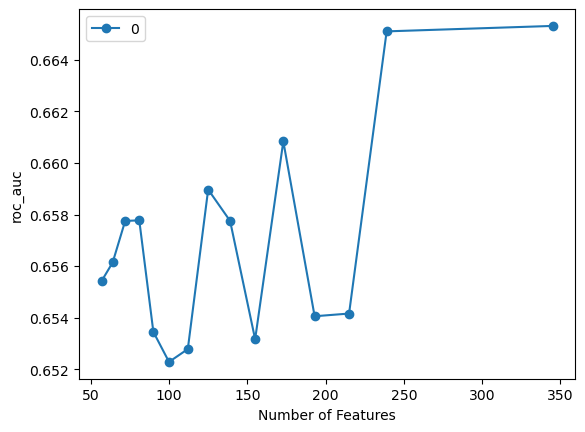

In [19]:
rfe.plot_model_scores()

In [20]:
rfe.get_feature_lists()

,Rank 1,Rank 2,Rank 3,Rank 4,Rank 5,Rank 6,Rank 7,Rank 8,Rank 9,Rank 10,...,Rank 336,Rank 337,Rank 338,Rank 339,Rank 340,Rank 341,Rank 342,Rank 343,Rank 344,Rank 345
0,season,week,div_game,target_days_since_previous_game,target_off_cumulative_score,target_off_cumulative_avg_score,target_off_cumulative_avg_score_change,opp_days_since_previous_game,opp_off_cumulative_score,opp_off_cumulative_avg_score,...,def_target_racr,def_target_racr_cumulative_average,def_target_racr_cumulative_average_change,def_target_wopr,def_target_wopr_cumulative_average,def_target_wopr_cumulative_average_change,def_target_special_teams_tds,def_target_special_teams_tds_cumulative_average,def_target_special_teams_tds_cumulative_averag...,is_home_target
1,is_home_target,off_target_passing_epa_cumulative_average,off_opp_passing_epa_cumulative_average,target_def_cumulative_avg_points_allowed,opp_def_cumulative_avg_points_allowed,target_off_cumulative_avg_score,off_target_rushing_first_downs_cumulative_average,opp_off_cumulative_avg_score,def_target_rushing_yards_cumulative_average,off_opp_rushing_fumbles_cumulative_average,...,,,,,,,,,,
2,is_home_target,off_target_passing_epa_cumulative_average,off_opp_passing_epa_cumulative_average,target_def_cumulative_avg_points_allowed,opp_def_cumulative_avg_points_allowed,target_off_cumulative_avg_score,off_target_rushing_first_downs_cumulative_average,opp_off_cumulative_avg_score,def_target_rushing_yards_cumulative_average,def_opp_rushing_yards_cumulative_average,...,,,,,,,,,,
3,is_home_target,off_target_passing_epa_cumulative_average,off_opp_passing_epa_cumulative_average,target_def_cumulative_avg_points_allowed,opp_def_cumulative_avg_points_allowed,def_target_rushing_yards_cumulative_average,opp_off_cumulative_avg_score,off_opp_passing_epa,target_off_cumulative_avg_score,def_opp_rushing_yards_cumulative_average,...,,,,,,,,,,
4,is_home_target,off_target_passing_epa_cumulative_average,off_opp_passing_epa_cumulative_average,target_def_cumulative_avg_points_allowed,opp_def_cumulative_avg_points_allowed,def_target_rushing_yards_cumulative_average,opp_off_cumulative_avg_score,off_opp_passing_epa,target_off_cumulative_avg_score,def_opp_rushing_yards_cumulative_average,...,,,,,,,,,,
5,is_home_target,off_opp_passing_epa_cumulative_average,opp_def_cumulative_avg_points_allowed,target_def_cumulative_avg_points_allowed,off_target_passing_epa_cumulative_average,opp_off_cumulative_avg_score,target_off_cumulative_avg_score,def_target_rushing_yards_cumulative_average,off_opp_rushing_fumbles_cumulative_average,off_opp_rushing_first_downs_cumulative_average,...,,,,,,,,,,
6,is_home_target,off_target_passing_epa_cumulative_average,off_opp_passing_epa_cumulative_average,opp_def_cumulative_avg_points_allowed,target_def_cumulative_avg_points_allowed,off_opp_rushing_first_downs_cumulative_average,off_opp_receiving_fumbles_lost_cumulative_aver...,opp_off_cumulative_avg_score,def_opp_rushing_yards_cumulative_average,off_opp_rushing_tds_cumulative_average,...,,,,,,,,,,
7,is_home_target,off_opp_passing_epa_cumulative_average,target_def_cumulative_avg_points_allowed,opp_def_cumulative_avg_points_allowed,target_off_cumulative_avg_score,off_target_passing_epa_cumulative_average,def_target_rushing_yards_cumulative_average,off_target_receiving_fumbles_lost_cumulative_a...,off_target_rushing_first_downs_cumulative_average,off_target_rushing_fumbles_cumulative_average,...,,,,,,,,,,
8,is_home_target,target_def_cumulative_avg_points_allowed,off_opp_passing_epa_cumulative_average,opp_def_cumulative_avg_points_allowed,off_target_passing_epa_cumulative_average,target_off_cumulative_avg_score,off_target_rushing_fumbles_cumulative_average,off_opp_passing_epa,off_opp_receiving_fumbles_lost_cumulative_aver...,def_opp_rushing_yards_cumulative_average,...,,,,,,,,,,
9,is_home_target,off_opp_passing_epa_cumulative_average,target_def_cumulative_avg_points_allowed,opp_def_cumulative_avg_points_allowed,off_target_passing_epa_cumulative_average,opp_off_cumulative_avg

In [22]:
best_num_feats = rfe.get_best_num_features(.005)
best_num_feats

173